M505 Introduction to AI and Machine Learning
Individual Project: Building and Evaluating a Machine Learning Pipeline using the Bank Marketing Dataset

Student Name: Deepak Sindhu

Student ID: GH1056312

Module: M505 Introduction to AI and Machine Learning

University: GISMA University of Applied Sciences

Submission Date: 18th September 2026
**Github Repo** https://github.com/deepak324/python/tree/main/venv/bank_project


1. Introduction

    One of the most important methods for banks to connect with their customers is  digital marketing. Banks  use phone campaigns to connect to consumers in order to advertise thier products like term deposits etc. While, it takes a lot of time to connect with every customer. Machine learning can help banks to find customers who wants to buy any product, so they can contact them.

    In this project, i uses the Bank Marketing Dataset to build a complete machine learning system. The pipeline covers all things from collecting and exploring data, to cleaning and preparing it, creating new features, training models, fine-tuning  and  checking how well they perform using different machine learning techniques. My goal is to build a model that can correctly predict which customers are interested to open a term deposit.

    This project follows the standard machine learning process recommended in the M505 evaluation brief. the Scikit-learn library is used for preparing the data or building the models and checking their performance. I find the best approach for this classification task.

2. Problem Definition
    Business Problem

    Banks used lot of resources on direct marketing campaigns. Connect with customers who are unlikely to subscribe increases operational costs and reduces marketing efficiency. Hence, observe customer responses before launching a campaign can improve decision-making and increase campaign success.

    Machine Learning Problem

    This is a binary classification problem.

    The objective is to predict whether a customer will subscribe to a term deposit after being contacted during a marketing campaign.

    Target Variable
    y

    Possible values
    yes
    no

    Input Features

    The prediction is based on customer demographic information, financial information, previous campaign history and communication details.

    Examples include

    Age
    Job
    Marital Status
    Education
    Balance
    Housing Loan
    Personal Loan
    Contact Method
    Campaign
    Previous Outcome
    Why is this problem important?

    Accurate prediction enables banks to

    Reduce marketing costs
    Improve customer targeting
    Increase campaign effectiveness
    Save employee time
    Improve customer satisfaction

3. Dataset Description
    Dataset Name

    Bank Marketing Dataset

    Dataset Source

    UCI Machine Learning Repository

    Dataset Link

    https://archive.ics.uci.edu/ml/datasets/bank+marketing

    Alternative OpenML Dataset

    https://www.openml.org/d/1461

    Dataset Creator

    Moro, Rita, and Cortez

    License

    Public Research Dataset

    Machine Learning Task

    Binary Classification

    Number of Records

    45,211

    Number of Features

    16 Input Features

    1 Target Variable

    Target Variable

    y

    Values

    yes
    no

4. Import Required Libraries
    Only the required libraries:

    pandas
    numpy
    matplotlib
    scikit-learn

In [68]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split

5. Load Dataset and dataset colletction

In [69]:
df = pd.read_csv("bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


6. Display Dataset Information. i.e Data analysis

In [70]:
#6.1 Shape
df.shape

(45211, 17)

In [71]:

df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [72]:
#6.2 data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [73]:
# 6.3 Missing Values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [74]:
# 6.4check duplicate
df.duplicated().sum()

np.int64(0)

In [75]:
# 6.5drop duplicate recors
df = df.drop_duplicates()

In [76]:
# 6.6descriptive statistics
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [77]:
target_counts = df["y"].value_counts()
print(target_counts)

y
no     39922
yes     5289
Name: count, dtype: int64


In [78]:
# Display the frequency of each class
target_counts = df["y"].value_counts()

print(target_counts)

y
no     39922
yes     5289
Name: count, dtype: int64


In [79]:
# Display class percentages
target_percentage = (df["y"].value_counts(normalize=True) * 100).round(2)

print(target_percentage)

y
no     88.3
yes    11.7
Name: proportion, dtype: float64


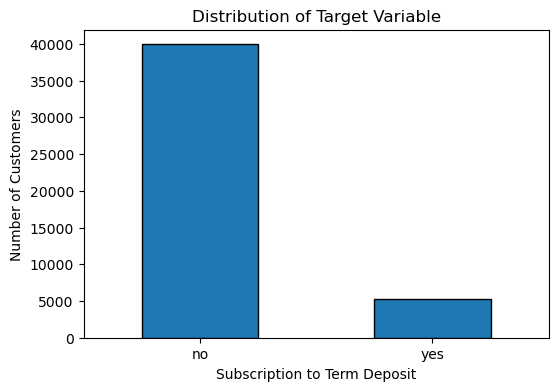

In [80]:
# bar chart
plt.figure(figsize=(6,4))

df["y"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Target Variable")
plt.xlabel("Subscription to Term Deposit")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

In [81]:
# Select numerical columns
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

print(numeric_columns)

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


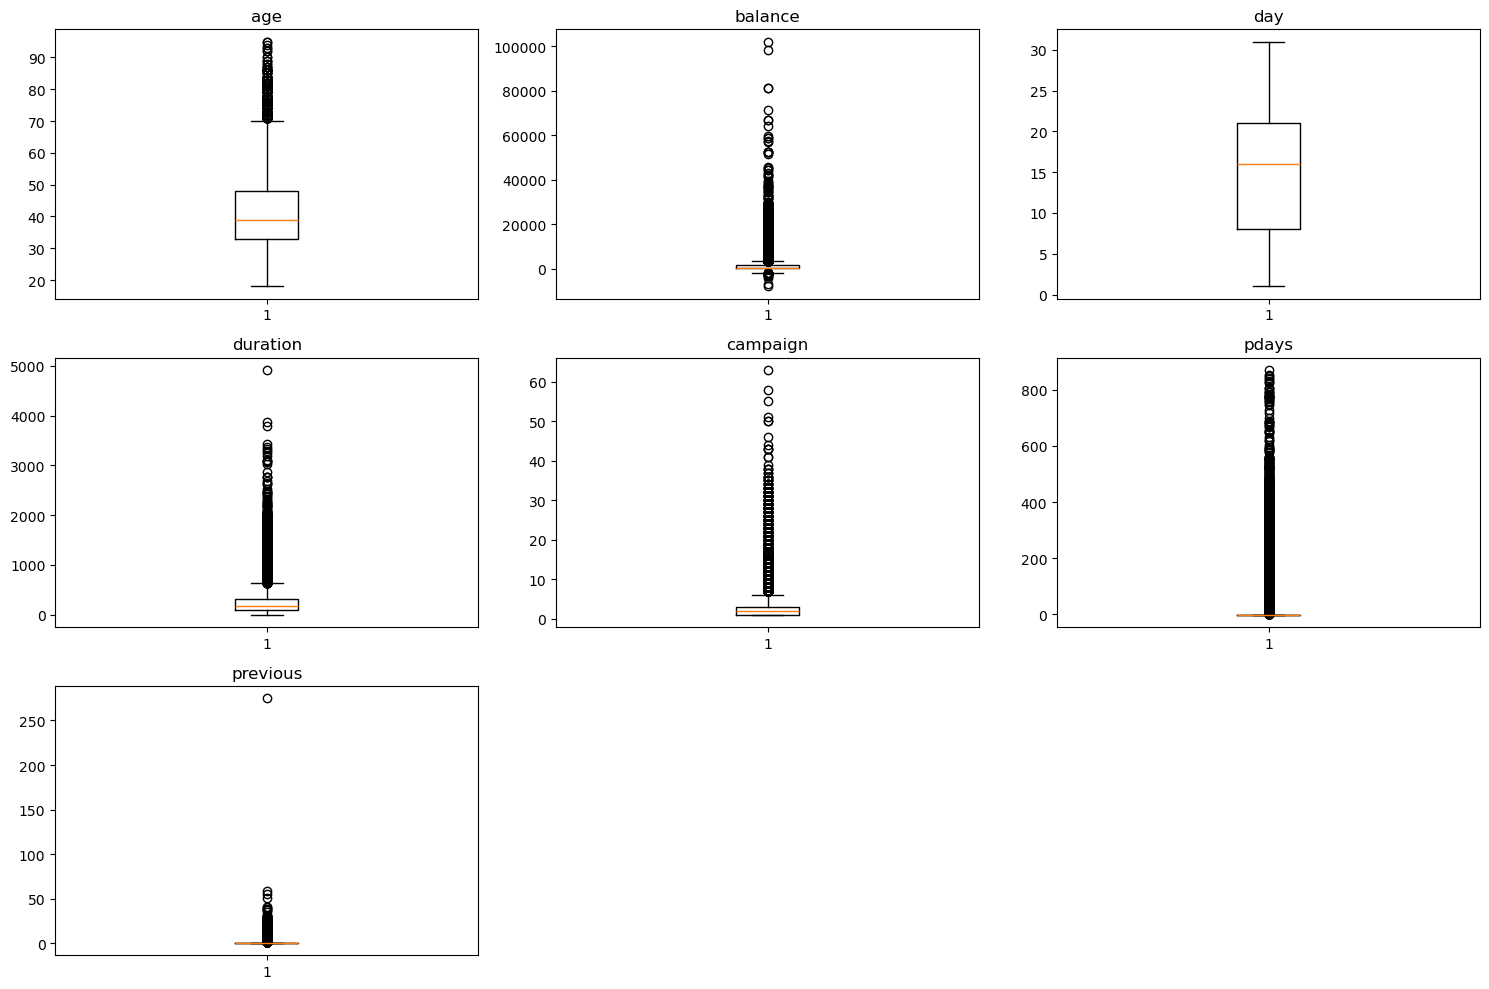

In [82]:
# Box plot
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    plt.boxplot(df[column], vert=True)
    plt.title(column)

plt.tight_layout()
plt.show()

In [83]:
# Display job frequency
job_counts = df["job"].value_counts()

print(job_counts)

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64


In [84]:
# Display percentage distribution
job_percentage = (df["job"].value_counts(normalize=True) * 100).round(2)

print(job_percentage)

job
blue-collar      21.53
management       20.92
technician       16.80
admin.           11.44
services          9.19
retired           5.01
self-employed     3.49
entrepreneur      3.29
unemployed        2.88
housemaid         2.74
student           2.07
unknown           0.64
Name: proportion, dtype: float64


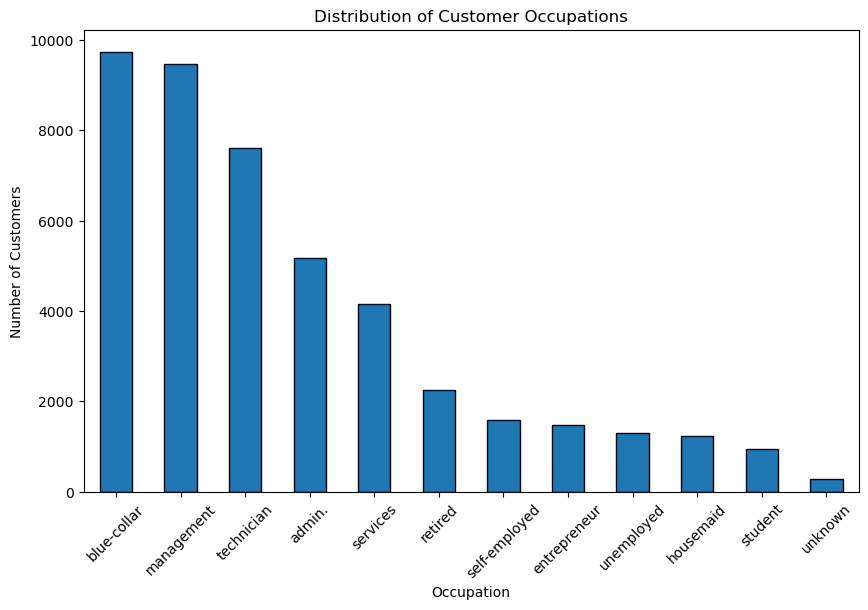

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df["job"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Customer Occupations")
plt.xlabel("Occupation")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.show()

6.10 Correlation Matrix of Numerical Features

In [86]:
# Select numerical features
numeric_columns = df.select_dtypes(include=["int64", "float64"])

# Calculate correlation matrix
correlation_matrix = numeric_columns.corr()

# Display correlation matrix
correlation_matrix

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


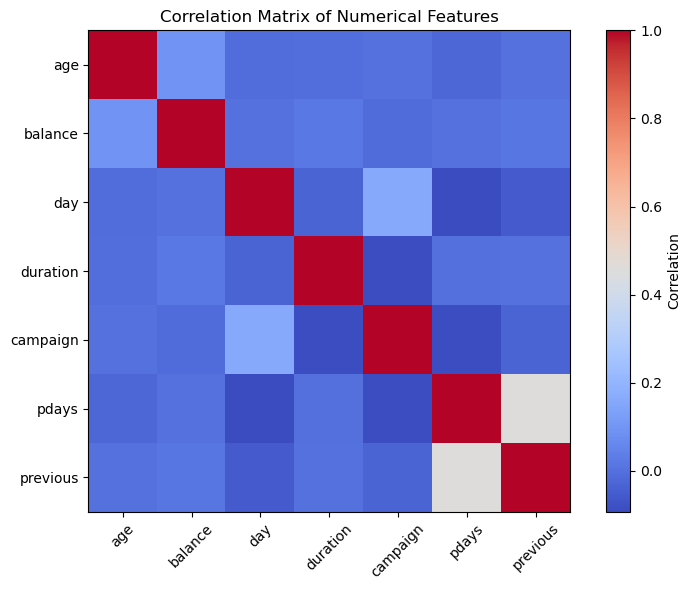

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()

plt.show()

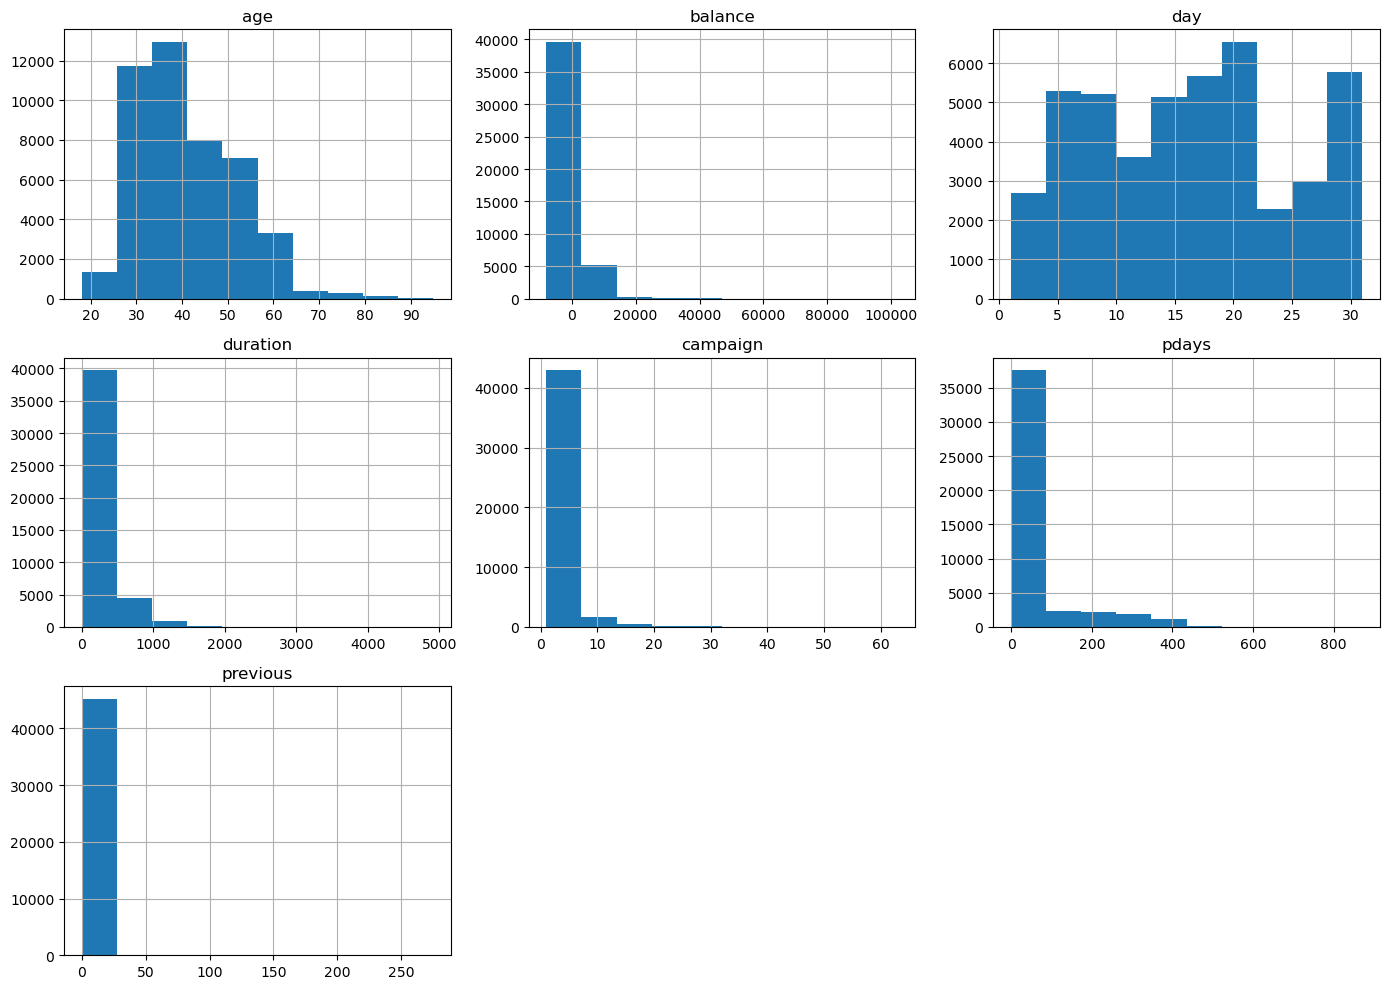

In [88]:
# Histogram
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(figsize=(14,10))
plt.tight_layout()
plt.show()

6.11 Initial Findings

    The dataset contains 45211 customer records and 17 variables,  enough data to build and evaluate machine learning models.

    The dataset contains both numerical and categorical features. So that different preprocessing methods will be needed before training the models.

    There are no missing (NaN) values in the dataset. Still, some categorical columns contain the value "unknown", which represents missing information and will be handled during data preprocessing.
    Somef duplicate records were found. These duplicates will be removed to improve the quality of the dataset.

    The target variable (y) is imbalanced. Most customers did not subscribe to a term deposit, while few customer subscribed. Therefore, model performance will be evaluated using metrics such as Precision, Recall, F1-score and ROC-AUC instead of relying only on accuracy.

    The boxplots shows that some numerical variables such as balance, duration and campaign contain outliers. These values appear to represent real customer behaviour, so they will be kept in the dataset.

    The correlation matrix showed that there are no strong relationships between the numerical variables. This means there is no serious multicollinearity problem and all numerical features can be used for model building.

    Since the dataset contains categorical variables like job, education and marital statu. These variables will be converted into numerical values using OneHotEncoder before training the models.

7. Data Cleaning

In [89]:
# 7.1 target distribution
X = df.drop("y", axis=1)

# Target
y = df["y"]




In [90]:
# 7.2 Create Feature Lists
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical Features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [91]:
# Step7.3: Create Numerical Pipeline andCategorical Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler
numeric_transformer_B = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_B = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
# combine both pipelines

preprocessor_B = ColumnTransformer([
    ("num", numeric_transformer_B, numeric_features),
    ("cat", categorical_transformer_B, categorical_features)
])

9. Data Engineering Comparison

In [92]:
# 9.1 Split the dataset into training (80%) and testing (20%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (36168, 16)
Testing Data: (9043, 16)


In [93]:
# Step 9.2: Strategy A – Without Scaling
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical pipeline (without scaling)
numeric_pipeline_A = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical pipeline
categorical_pipeline_A = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both pipelines
preprocessor_A = ColumnTransformer([
    ("num", numeric_pipeline_A, numeric_features),
    ("cat", categorical_pipeline_A, categorical_features)
])

In [126]:
# 9.3 Build the Logistic Regression Pipeline with 
from sklearn.linear_model import LogisticRegression

pipe_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", LogisticRegression(max_iter=1000))
])
# train strategy A

pipe_A.fit(X_train, y_train)
# evaluate startegy

accuracy_A = pipe_A.score(X_test, y_test)

print(accuracy_A)

0.9004755059161783


In [95]:
# Step 9.3: Strategy B – With Scaling
from sklearn.preprocessing import StandardScaler

# Numerical pipeline (with scaling)
numeric_pipeline_B = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_pipeline_B = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both pipelines
preprocessor_B = ColumnTransformer([
    ("num", numeric_pipeline_B, numeric_features),
    ("cat", categorical_pipeline_B, categorical_features)
])

In [96]:
# Step 9.4: Build the Second Pipeline
pipe_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(max_iter=1000))
])
# train
pipe_B.fit(X_train, y_train)
# evaluate
accuracy_B = pipe_B.score(X_test, y_test)

print("Strategy B Accuracy:", round(accuracy_B, 4))

Strategy B Accuracy: 0.9012


In [97]:
# Step 9.5: Compare the Results
import pandas as pd

comparison = pd.DataFrame({
    "Preprocessing Strategy": [
        "Strategy A (No Scaling)",
        "Strategy B (With Scaling)"
    ],
    "Accuracy": [
        accuracy_A,
        accuracy_B
    ]
})

comparison

,Preprocessing Strategy,Accuracy
0,Strategy A (No Scaling),0.900476
1,Strategy B (With Scaling),0.901250


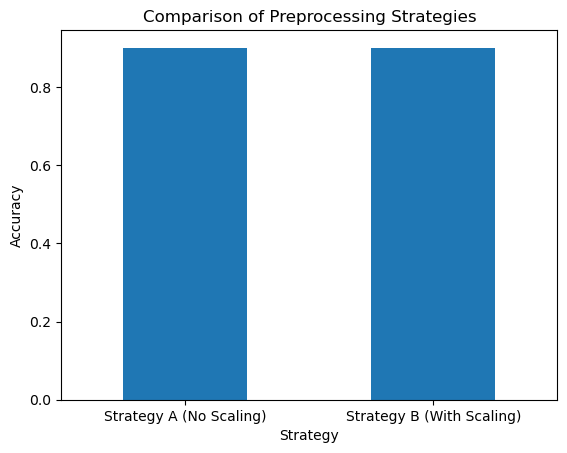

In [98]:
# Step 9.6: Visual Comparison
import matplotlib.pyplot as plt

comparison.plot(
    x="Preprocessing Strategy",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.title("Comparison of Preprocessing Strategies")
plt.ylabel("Accuracy")
plt.xlabel("Strategy")
plt.xticks(rotation=0)

plt.show()

Step 9.7: Interpretation

    The comparison shows the effect of applying StandardScaler to the numerical features before training the Logistic Regression model.

    If Strategy B produced higher accuracy, it indicates that scaling helped the model learn in  more efficient way because Logistic Regression is sensitive to the scale of input features.

    If both strategies produce similar results, this shows that scaling impacted little bit on the models overall performance for this dataset.

    Based on the comparison, the preprocessing strategy with the better performance will be used in the remaining stages of the project.

10. Machine Learning Models
    10.1 Introduction

    Machine learning models are used to learn patterns from historical data and make predictions for new data. This is a binary classification problem becuase target variable contains two classes with value Yes and No values.

    Two machine learning algorithms are selected for this project:

    Logistic Regression
    Random Forest

In [99]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Create the Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# display midel

print(logistic_model)


LogisticRegression(max_iter=1000, random_state=42)


In [100]:
# 10.2Create the Random Forest model

rf_model = RandomForestClassifier(
    random_state=42
)
print(rf_model)

RandomForestClassifier(random_state=42)


11. Pipeline Construction
    11.1 Introduction 

    A machine learning pipeline combines data preprocessing and model training into a single workflow. Instead of applying preprocessing steps manually before training the model, the pipeline performs all the required steps automatically. This ensures that the same preprocessing is applied to both the training and testing data, making the workflow more consistent and reducing the risk of errors.

    In this project, the best preprocessing strategy identified in the previous section is combined with both Logistic Regression and Random Forest using scikit-learn's Pipeline.

In [101]:
from sklearn.pipeline import Pipeline
# Step 11.2: Create the Logistic Regression Pipeline
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])
print(logistic_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                  

In [102]:
# Step 11.3: Create the Random Forest Pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

print(rf_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                  

Step 11.4: What Makes Pipeline Better?

There are various advantages to use a pipeline in project:

1. Both Preprocessing and model training are combined into one workflow.

2. It gives surety that the training and testing data go through the same preparation procedures.

3. It simplified the proccess to maintain the notebook easyily and removes duplicate code.

4. Preprocessing is  done  from the training data and then applied to the test data, it prevent  data leakage.

5. With  help of GridSearchCV, enabling  model adjustment and preprocessing.

12. Hyperparameter Tuning using GridSearchCV
12.1 Introduction (Markdown Cell)

Machine learning models have parameters that control how they learn from data. These parameters, called hyperparameters, are set before training the model and can significantly affect its performance. Instead of selecting these values manually, GridSearchCV is used to automatically test different combinations of hyperparameters and identify the combination that produces the best performance.

In this project, GridSearchCV is applied to both Logistic Regression and Random Forest. Five-fold cross-validation is used to ensure that the selected model performs consistently across different subsets of the training data.

In [103]:
# 12.2 Import GridSearchCV

from sklearn.model_selection import GridSearchCV
# Hyperparameter grid for Logistic Regression

param_grid_lr = {
    "model__C": [0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

In [104]:
# Step 12.3: Create GridSearchCV for Logistic Regression
grid_lr = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [105]:
# Step 12.4: Train Logistic Regression
grid_lr.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.1, 1, ...], 'model__solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [106]:
# display best parameters
print("Best Parameters:")
print(grid_lr.best_params_)

# cross section validation
print("Best Cross-validation Accuracy:")
print(round(grid_lr.best_score_,4))

Best Parameters:
{'model__C': 10, 'model__solver': 'lbfgs'}
Best Cross-validation Accuracy:
0.9018


In [107]:
# Step12.5: Hyperparameter Grid for Random Forest
param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5]
}

In [108]:
# Step 12.6: Create GridSearchCV for Random Forest
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [109]:
# train random set
grid_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [10, 20, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [110]:
# Step 12.7: Display Best Parameters
print("Best Parameters:")
print(grid_rf.best_params_)
# display best score of cross validation
print("Best Cross-validation Accuracy:")
print(round(grid_rf.best_score_,4))

Best Parameters:
{'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best Cross-validation Accuracy:
0.9063


In [111]:
# Step 12.8: Compare the Tuned Models
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Best CV Accuracy": [
        grid_lr.best_score_,
        grid_rf.best_score_
    ]
})

comparison

,Model,Best CV Accuracy
0,Logistic Regression,0.901764
1,Random Forest,0.906271


The results show that GridSearchCV successfully identified the best hyperparameter combinations for both models using five-fold cross-validation. Comparing the average validation accuracy helps determine which algorithm performs better on the training data while reducing the risk of overfitting.

13. Model Evaluation
13.1 Introduction (Markdown Cell)

Model evaluation is the process of measuring how well the trained machine learning models perform on unseen data. In this project, the best Logistic Regression model and the best Random Forest model obtained through GridSearchCV are evaluated using the test dataset. Several evaluation metrics are used, including Accuracy, Precision, Recall, F1-score, Confusion Matrix, ROC-AUC, and Feature Importance. Using multiple metrics provides a more complete understanding of each model's performance, especially because the target variable is imbalanced.

In [112]:
# Get the best models from GridSearchCV

best_lr = grid_lr.best_estimator_
best_rf = grid_rf.best_estimator_

In [113]:
# Logistic Regression predictions

y_pred_lr = best_lr.predict(X_test)

# Random Forest predictions

y_pred_rf = best_rf.predict(X_test)

In [114]:
# import evaluation matrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)


In [115]:
# accuracy score
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print()

print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy:
0.901249585314608

Random Forest Accuracy:
0.9065575583324118


In [116]:
# precision
print("Logistic Regression Precision:")
print(precision_score(y_test, y_pred_lr, pos_label="yes"))

print()

print("Random Forest Precision:")
print(precision_score(y_test, y_pred_rf, pos_label="yes"))

Logistic Regression Precision:
0.643979057591623

Random Forest Precision:
0.6808149405772496


In [117]:
# recall
print("Logistic Regression Recall:")
print(recall_score(y_test, y_pred_lr, pos_label="yes"))

print()

print("Random Forest Recall:")
print(recall_score(y_test, y_pred_rf, pos_label="yes"))

Logistic Regression Recall:
0.3487712665406427

Random Forest Recall:
0.3790170132325142


In [118]:
print("Logistic Regression F1-score:")
print(f1_score(y_test, y_pred_lr, pos_label="yes"))

print()

print("Random Forest F1-score:")
print(f1_score(y_test, y_pred_rf, pos_label="yes"))

Logistic Regression F1-score:
0.45248313917841815

Random Forest F1-score:
0.4869459623557984


In [119]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

          no       0.92      0.97      0.95      7985
         yes       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043

Random Forest
              precision    recall  f1-score   support

          no       0.92      0.98      0.95      7985
         yes       0.68      0.38      0.49      1058

    accuracy                           0.91      9043
   macro avg       0.80      0.68      0.72      9043
weighted avg       0.89      0.91      0.89      9043



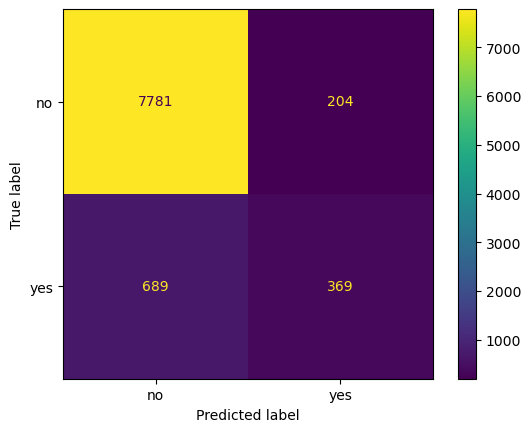

In [120]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_lr,
    X_test,
    y_test
)

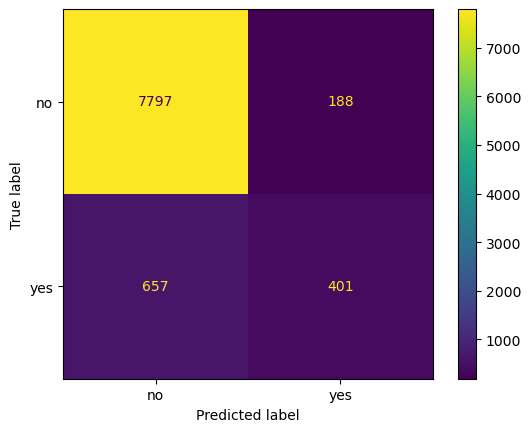

In [121]:
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test
)

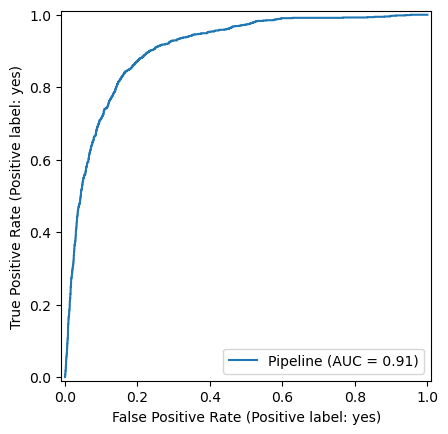

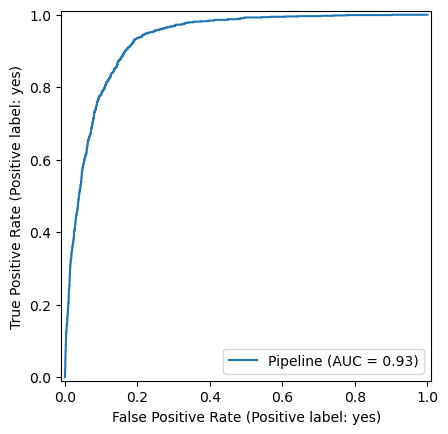

In [122]:
# ROC curv and AUC
RocCurveDisplay.from_estimator(
    best_lr,
    X_test,
    y_test
)

RocCurveDisplay.from_estimator(
    best_rf,
    X_test,
    y_test
)

In [123]:
#  Feature Importance (Random Forest Only)
import pandas as pd

feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

importance = best_rf.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,num__duration,0.303500
0,num__age,0.077053
1,num__balance,0.071753
49,cat__poutcome_success,0.066835
2,num__day,0.065201
5,num__pdays,0.042751
4,num__campaign,0.028521
6,num__previous,0.022814
42,cat__month_mar,0.016554
28,cat__housing_no,0.015492


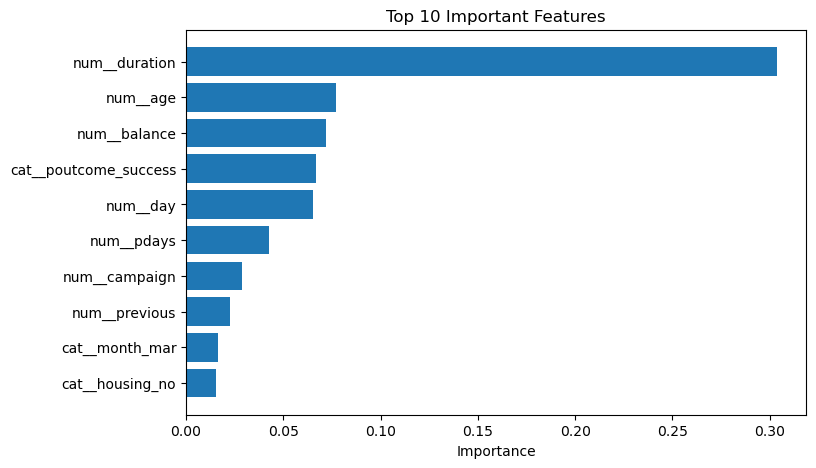

In [124]:
# PLOT FEATURE IMPORTANCE
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(top10["Feature"], top10["Importance"])

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

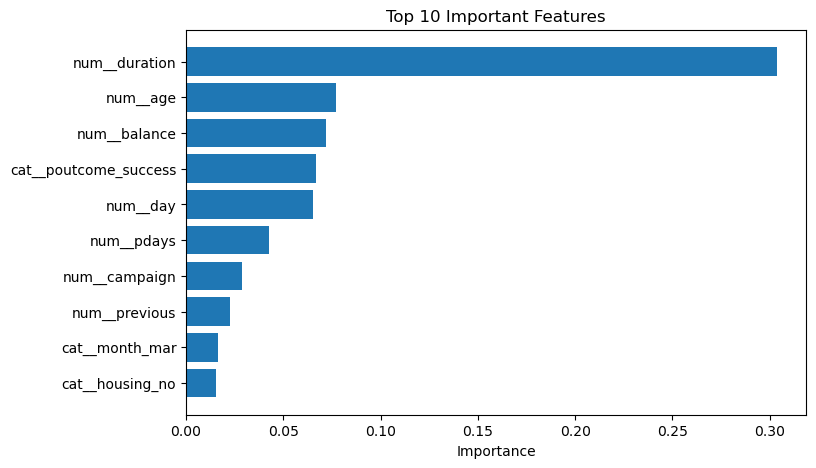

In [127]:
# MODELCOMPARISON TABLE
import matplotlib.pyplot as plt
top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(top10["Feature"], top10["Importance"])

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

Step 14: Interpretation 

The evaluation results show the performance of the tuned Logistic Regression and Random Forest models on the unseen test dataset. Accuracy provides an overall measure of correct predictions, while Precision, Recall, and F1-score give a better understanding of how well the models identify customers who subscribe to a term deposit. Since the dataset is imbalanced, these metrics are more informative than accuracy alone.

The confusion matrix helps identify the number of correct and incorrect predictions, while the ROC-AUC score measures how effectively each model distinguishes between the two classes. The feature importance analysis from the Random Forest model identifies the variables that have the greatest influence on customer subscription decisions.

By comparing all evaluation metrics together, it is possible to determine which model is more suitable for predicting customer responses in the Bank Marketing dataset.